# Máquina de Vetores de Suporte (SVM)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

In [ ]:
#  Gerando dados sintéticos
X, y = make_blobs(n_samples=60, centers=2, random_state=42, cluster_std=0.8)

In [3]:
print(X)

[[ 5.82219407  1.55855351]
 [ 5.27270439  1.24565972]
 [-2.99056291 10.49610868]
 [ 4.71754088  2.74808568]
 [-3.23561688  7.88444317]
 [-3.69201522  8.43841076]
 [ 4.84591915  1.91361295]
 [-2.87993178  8.64170233]
 [ 5.37220053  2.23617057]
 [-2.5199954   8.16811739]
 [ 4.51085027  2.29641037]
 [-2.98970857  8.78093113]
 [ 3.10486186  1.95195858]
 [ 4.611218    3.22488461]
 [ 4.61210942  1.03822725]
 [-2.24993045  8.7062203 ]
 [ 4.71328746  0.38311455]
 [-2.31562781  7.48366193]
 [-3.42999248  9.31484454]
 [ 4.92899532  3.20359894]
 [ 4.70951649  1.7339638 ]
 [-1.24582737  9.62823391]
 [-2.34210675  7.44655003]
 [ 4.21607067  2.38378363]
 [-3.18057164  8.76691623]
 [ 4.32619231  0.80235773]
 [ 6.14882756  2.11283193]
 [ 3.99308395  1.57176405]
 [ 4.07823636  1.71103997]
 [-2.45517506  7.87448758]
 [-3.3942656   8.05732083]
 [ 5.28989949  3.05816171]
 [-2.23430299  7.603854  ]
 [-3.05073522  9.50362716]
 [-2.24418688  9.79472223]
 [ 5.55413709  2.57471611]
 [-2.69652032  8.82697656]
 

In [4]:
print(y)

[1 1 0 1 0 0 1 0 1 0 1 0 1 1 1 0 1 0 0 1 1 0 0 1 0 1 1 1 1 0 0 1 0 0 0 1 0
 0 1 1 0 1 1 1 1 0 0 1 0 0 0 1 1 0 1 0 1 0 0 0]


# Treino

In [ ]:
model = SVC(kernel="linear", C=1.0) 
# o "C" é um suporte que é um parâmetro que a gente faz um trade-off
# quanto maior o "C" ele tem menos tolerância a erros 
# quanto menor o "C" maior a tolerância a erros

In [6]:
model.fit(X,y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [7]:
print(model.intercept_)
print(model.coef_)

[1.01012031]
[[ 0.20762547 -0.20463694]]


In [8]:
# desenha a fronteira e margens
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

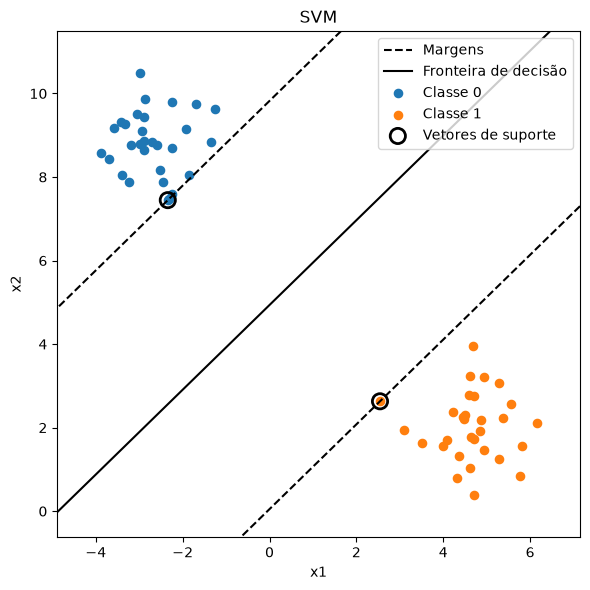

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Classe 0", s=35)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Classe 1", s=35)

plt.contour(xx, yy, Z, levels=[-1], linestyles=["--"], colors="k")
plt.contour(xx, yy, Z, levels=[0],  linestyles=["-"],  colors="k")
plt.contour(xx, yy, Z, levels=[1],  linestyles=["--"], colors="k")
sv = model.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=120, facecolors="none", linewidths=2, label="Vetores de suporte", edgecolors="k")
handles = [
    Line2D([0], [0], linestyle="--", color="k", label="Margens"),
    Line2D([0], [0], linestyle="-",  color="k", label="Fronteira de decisão")
]
plt.legend(handles=handles + plt.gca().get_legend_handles_labels()[0], loc="best")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("SVM")
plt.tight_layout()
plt.show()